In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [2]:
#loading the Dataset and converting it indo Dataframes
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [5]:
#selecting only two features
X = df.iloc[:,2:]
print(X)


     petal length (cm)  petal width (cm)
0                  1.4               0.2
1                  1.4               0.2
2                  1.3               0.2
3                  1.5               0.2
4                  1.4               0.2
..                 ...               ...
145                5.2               2.3
146                5.0               1.9
147                5.2               2.0
148                5.4               2.3
149                5.1               1.8

[150 rows x 2 columns]


In [13]:
#creating a Kmean
k = 3
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)
#assigning back to the df
df["Cluster"] = kmeans.fit_predict(X)

centroids = kmeans.cluster_centers_
print(centroids)

[[5.59583333 2.0375    ]
 [1.462      0.246     ]
 [4.26923077 1.34230769]]


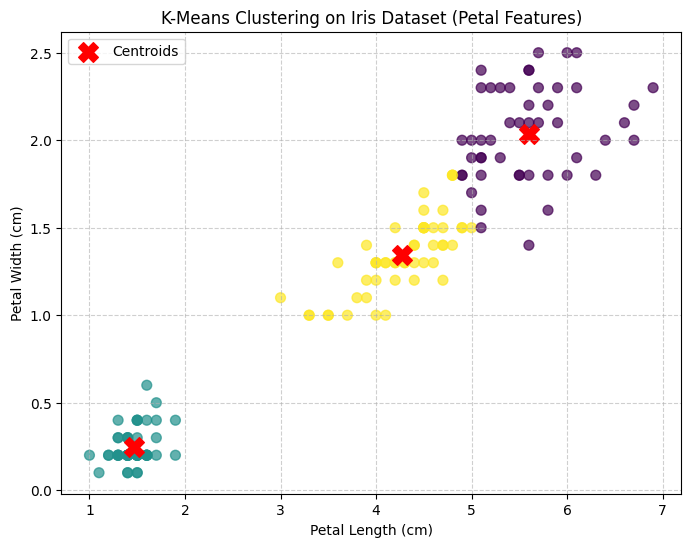

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(df['petal length (cm)'], df['petal width (cm)'],
            c=df['Cluster'], cmap='viridis', s=50, alpha=0.7)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=200, marker='X', label='Centroids')

plt.title('K-Means Clustering on Iris Dataset (Petal Features)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_cluster_regions(X, centroids, title="Cluster Regions"):
    X = np.asarray(X)
    centroids = np.asarray(centroids)

    buffer = 0.5
    x_min, x_max = X[:, 0].min() - buffer, X[:, 0].max() + buffer
    y_min, y_max = X[:, 1].min() - buffer, X[:, 1].max() + buffer

    resolution = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    distances = np.linalg.norm(grid_points[:, np.newaxis] - centroids, axis=2)
    Z = np.argmin(distances, axis=1)
    Z = Z.reshape(xx.shape)

    colors = ['#fbc5d8', '#a1d99b', '#e0e0e0', '#fee08b', '#fdae61']


    if len(centroids) > len(colors):
        cmap = plt.cm.get_cmap('Pastel1', len(centroids))
    else:
        cmap = ListedColormap(colors[:len(centroids)])

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.pcolormesh(xx, yy, Z, cmap=cmap, alpha=0.8, shading='auto')
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5)

    ax.scatter(X[:, 0], X[:, 1], c='k', s=2, alpha=0.7)
    ax.scatter(centroids[:, 0], centroids[:, 1], marker='o', s=120, c='white', edgecolors='k', zorder=5)
    ax.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=50, c='k', zorder=6)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel(r'$x_1$', fontsize=12)
    ax.set_ylabel(r'$x_2$', fontsize=12)
    ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

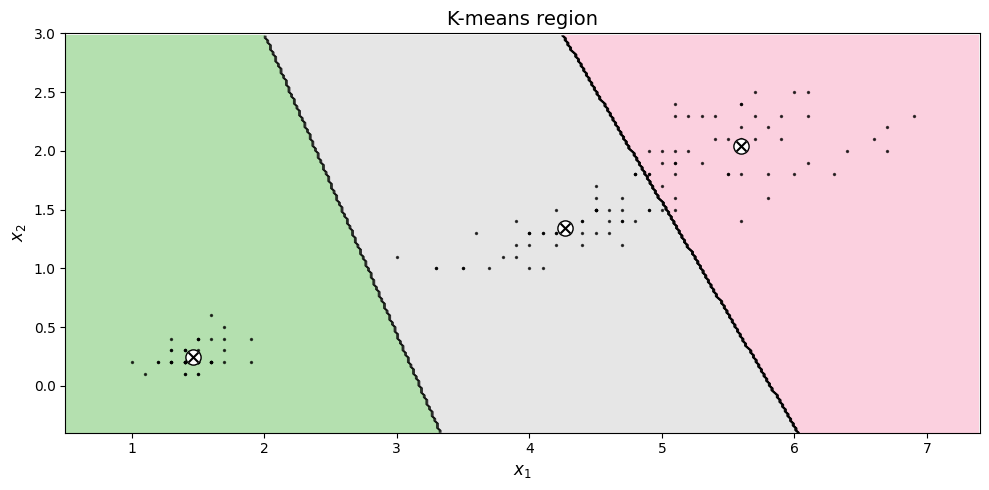

In [14]:
plot_cluster_regions(X, centroids, title='K-means region')